In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline



In [3]:
df = pd.read_csv("E:\\Learning\\Krish\\Linear regression\\HeightWeightdataset\\weight-height.csv")


In [4]:
df.head()

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801


Text(0, 0.5, 'Height')

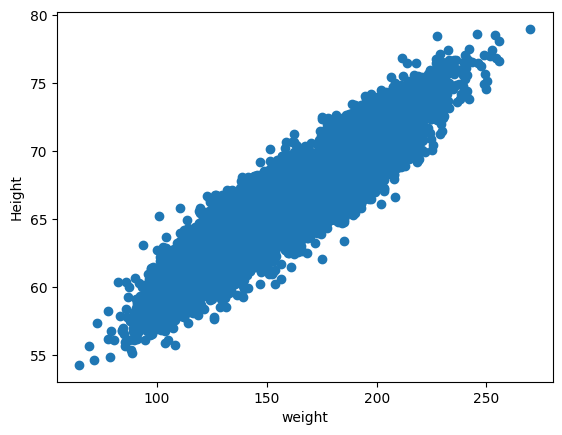

In [5]:
#scatter plot

plt.scatter(df["Weight"],df["Height"])
plt.xlabel("weight")
plt.ylabel("Height")

In [6]:
df.corr()

,Height,Weight
Height,1.000000,0.924756
Weight,0.924756,1.000000


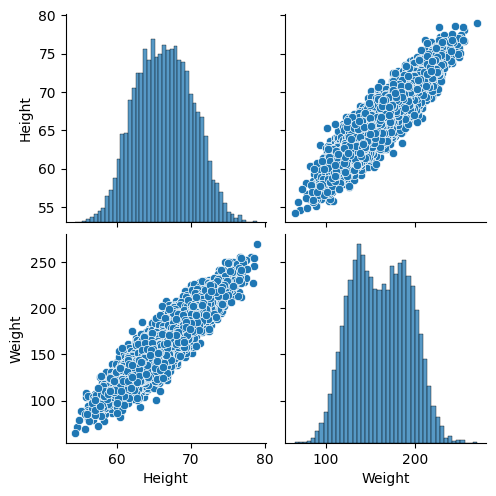

In [7]:
import seaborn as sns
sns.pairplot(df)

In [8]:
#independent and dependent features 

X = df[["Weight"]]
Y = df["Height"] # this element can be in series form or can be in 1d array
#indipendent feature should be in dataframe or it can also be two dimenstion array

np.array(X).shape



(10000, 1)

In [9]:
X.head()

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801


In [10]:
## Train test split 
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.25, random_state=42)




In [11]:
#STANDARDIZATION 
from sklearn.preprocessing import StandardScaler


In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)



In [13]:
X_test = scaler.transform(X_test)

In [18]:
X_test.mean()

np.float64(0.026182132030945018)

In [19]:
#Apply linear regression on this data 
from sklearn.linear_model import LinearRegression

In [20]:
regression = LinearRegression()

In [21]:
regression.fit(X_train,Y_train)

LinearRegression()

In [22]:
print(f"Coefficient or slop is:-  {regression.coef_}")
print(f"Intercept is :- {regression.intercept_}")

Coefficient or slop is:-  [3.5520765]
Intercept is :- 66.34834766153067


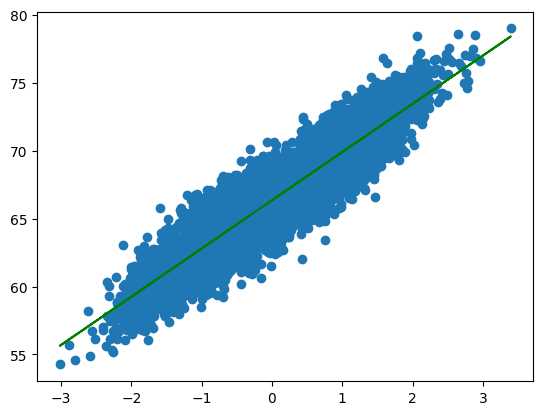

In [23]:
#plot training data plot best fit line

plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train),color='green')

###prediction for the test data 
1. predict the height output = intercept + coeff_(weight)
2. y_pred_test = 66.34834766153067 +3.5520765 (X_test)
y_pred = regression.predict(X_test)


Coefficient or slop is:-  [3.5520765]
Intercept is :- 66.34834766153067

In [28]:
y_pred = regression.predict(X_test)
print(y_pred)

[67.66673256 70.11227616 67.3452232  ... 62.20315456 66.80250233
 66.55658642]


In [29]:
#performance metrix
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error



In [26]:
mse = mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse= np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2.1245002936077957
1.1618686242313918
1.4575665657553332


## R square 
 Formula

R^2 = 1- SSR/SST
Sum of square , sum of total



In [27]:
from sklearn.metrics import r2_score,adjusted_rand_score

score = r2_score(Y_test,y_pred)
print(score)

0.8574288810712688


In [88]:
#display adjusted r-squared

1-(1-score)*len((Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.8573147328575549